# プロジェクト最終レビュー

このノートブックでは、プロジェクト全体のコードベースとドキュメントをレビューし、最終的な品質確認を行います。以下のセクションでは、改善案の実施結果が正確に反映されているかを確認します。

## 📦 セットアップ

必要なライブラリをインストール・インポート

In [1]:
# 必要なライブラリのインストール（初回のみ）
import subprocess
import sys

def install_if_missing(package):
    try:
        __import__(package)
        print(f"✓ {package} はインストール済みです")
    except ImportError:
        print(f"インストール中: {package}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package, "-q"])
        print(f"✓ {package} をインストールしました")

# 必要なパッケージ
packages = ['torch', 'transformers', 'datasets', 'numpy', 'pandas', 'scikit-learn', 'matplotlib']

for package in packages:
    install_if_missing(package)

print("\n✅ すべての準備が完了しました！")

✓ torch はインストール済みです


/home/abemc/project_root/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓ transformers はインストール済みです
✓ datasets はインストール済みです
✓ numpy はインストール済みです
✓ pandas はインストール済みです
インストール中: scikit-learn...
✓ scikit-learn をインストールしました
✓ matplotlib はインストール済みです

✅ すべての準備が完了しました！


In [2]:
# ライブラリのインポート
import torch
import numpy as np
import pandas as pd
from transformers import AutoTokenizer, AutoModelForCausalLM, AutoModel, pipeline
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import matplotlib
import warnings
warnings.filterwarnings('ignore')

# 日本語フォント設定（文字化け対策）
matplotlib.rcParams['font.sans-serif'] = ['DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 設定
plt.style.use('seaborn-v0_8-darkgrid')
torch.set_printoptions(precision=4, sci_mode=False)
np.set_printoptions(precision=4, suppress=True)

print(f"PyTorch バージョン: {torch.__version__}")
print(f"Transformers バージョン: {AutoTokenizer.__module__}")
print(f"GPU 利用可能: {torch.cuda.is_available()}")
print(f"使用デバイス: {torch.device('cuda' if torch.cuda.is_available() else 'cpu')}")

PyTorch バージョン: 2.11.0+cu130
Transformers バージョン: transformers.models.auto.tokenization_auto
GPU 利用可能: True
使用デバイス: cuda


## 1️⃣ 最初の推論：Hello LLM

Hugging Face のパイプラインを使った最も簡単な推論

In [ ]:
# 例1: テキスト分類（感情分析）
print("="*60)
print("例1: 感情分析")
print("="*60)

# ステップ1: 分類器を作成（自動でモデルをダウンロード）
from transformers import pipeline  # 必要な場合はインポート
classifier = pipeline(  # type: ignore
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english"
)

# ステップ2: テキストを準備
texts = [
    "I absolutely love this product!",
    "This is terrible and disappointing.",
    "It's okay, nothing special."
]

# ステップ3: テキスト分析を実行
results = classifier(texts)

# ステップ4: 結果を表示
for text, result in zip(texts, results):
    print(f"\nテキスト: {text}")
    print(f"  感情: {result['label']}")                                     # labelは感情の種類（例: POSITIVE, NEGATIVE） result['label']は感情の種類（例: POSITIVE, NEGATIVE）
    print(f"  確信度: {result['score']:.4f} ({result['score']*100:.2f}%)")  # scoreはモデルの確信度 4fは小数点以下4桁まで表示、100倍してパーセンテージ表示

例1: 感情分析


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 269.22it/s]



テキスト: I absolutely love this product!
  感情: POSITIVE
  確信度: 0.9999 (99.99%)

テキスト: This is terrible and disappointing.
  感情: NEGATIVE
  確信度: 0.9998 (99.98%)

テキスト: It's okay, nothing special.
  感情: NEGATIVE
  確信度: 0.8190 (81.90%)


In [4]:
# 例2: ゼロショット分類
print("\n" + "="*60)
print("例2: ゼロショット分類（テキスト分類の高度な例）")
print("="*60)

# ゼロショット分類パイプラインを作成
classifier = pipeline(  # type: ignore
    "zero-shot-classification",
    model="facebook/bart-large-mnli"
)

# テキストと候補ラベル
text_to_classify = "The weather is beautiful today. I love sunny days!"

candidate_labels = ["weather", "emotion", "time", "activity"]

# 分類実行
result = classifier(text_to_classify, candidate_labels)

print(f"\nテキスト: {text_to_classify}")
print(f"候補ラベル: {candidate_labels}")
print(f"\n分類結果:")

for label, score in zip(result['labels'], result['scores']):
    print(f"  {label:15} スコア: {score:.4f} ({score*100:.2f}%)")

print(f"\n最も関連性の高いラベル: {result['labels'][0]} ({result['scores'][0]:.4f})")


例2: ゼロショット分類（テキスト分類の高度な例）


Loading weights: 100%|██████████| 515/515 [00:02<00:00, 198.11it/s]



テキスト: The weather is beautiful today. I love sunny days!
候補ラベル: ['weather', 'emotion', 'time', 'activity']

分類結果:
  weather         スコア: 0.8018 (80.18%)
  emotion         スコア: 0.0716 (7.16%)
  time            スコア: 0.0709 (7.09%)
  activity        スコア: 0.0557 (5.57%)

最も関連性の高いラベル: weather (0.8018)


## 2️⃣ Tokenizer の詳細動作

テキストがどのようにトークン化されるのか詳しく見てみましょう

In [5]:
# Tokenizer をロード
tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')

print("="*60)
print("Tokenizer の動作を追跡")
print("="*60)

# テスト用テキスト
text = "Hello, how are you? I'm learning about LLMs!"

print(f"\n元のテキスト: {text}")
print("-" * 60)

# ステップ1: トークン化
tokens = tokenizer.tokenize(text)
print(f"\nステップ1: トークン化")
print(f"トークン: {tokens}")
print(f"トークン数: {len(tokens)}")

# ステップ2: トークンID化
token_ids = tokenizer.convert_tokens_to_ids(tokens)
print(f"\nステップ2: トークンID化")
print(f"トークンID: {token_ids}")

# ステップ3: 復元
recovered_tokens = tokenizer.convert_ids_to_tokens(token_ids)
recovered_text = tokenizer.convert_tokens_to_string(recovered_tokens)
print(f"\nステップ3: テキストに復元")
print(f"復元テキスト: {recovered_text}")

# ステップ4: encode を使った一括処理（特殊トークン付き）
encoded = tokenizer.encode(text, add_special_tokens=True)
print(f"\nステップ4: encode（特殊トークン付き）")
print(f"エンコード結果: {encoded}")
print(f"先頭: {encoded[0]} = [CLS] トークン")
print(f"末尾: {encoded[-1]} = [SEP] トークン")

Tokenizer の動作を追跡

元のテキスト: Hello, how are you? I'm learning about LLMs!
------------------------------------------------------------

ステップ1: トークン化
トークン: ['hello', ',', 'how', 'are', 'you', '?', 'i', "'", 'm', 'learning', 'about', 'll', '##ms', '!']
トークン数: 14

ステップ2: トークンID化
トークンID: [7592, 1010, 2129, 2024, 2017, 1029, 1045, 1005, 1049, 4083, 2055, 2222, 5244, 999]

ステップ3: テキストに復元
復元テキスト: hello, how are you? i ' m learning about llms!

ステップ4: encode（特殊トークン付き）
エンコード結果: [101, 7592, 1010, 2129, 2024, 2017, 1029, 1045, 1005, 1049, 4083, 2055, 2222, 5244, 999, 102]
先頭: 101 = [CLS] トークン
末尾: 102 = [SEP] トークン


In [6]:
# バッチ処理（複数のテキストを効率的に処理）
print("\n" + "="*60)
print("バッチ処理と パディング・截断")
print("="*60)

texts_batch = [
    "Short text",
    "This is a medium length text that is a bit longer",
    "This is a much longer text " * 5  # 長いテキスト
]

# バッチ処理
encoded_batch = tokenizer(
    texts_batch,
    padding=True,      # パディング
    truncation=True,   # 截断
    max_length=50,
    return_tensors='pt'
)

print(f"\n入力テキスト数: {len(texts_batch)}")
for i, text in enumerate(texts_batch):
    print(f"  テキスト{i+1}: {text[:40]}... (長さ: {len(text)}文字)")

print(f"\n処理結果:")
print(f"  Input IDs 形状: {encoded_batch['input_ids'].shape}")
print(f"  Attention Mask 形状: {encoded_batch['attention_mask'].shape}")
print(f"\nすべてのテキストが同じ長さ ({encoded_batch['input_ids'].shape[1]}) に統一されました")


バッチ処理と パディング・截断

入力テキスト数: 3
  テキスト1: Short text... (長さ: 10文字)
  テキスト2: This is a medium length text that is a b... (長さ: 49文字)
  テキスト3: This is a much longer text This is a muc... (長さ: 135文字)

処理結果:
  Input IDs 形状: torch.Size([3, 32])
  Attention Mask 形状: torch.Size([3, 32])

すべてのテキストが同じ長さ (32) に統一されました


## 3️⃣ 埋め込みベクトルの可視化

Embedding がテキストを数値で表現する方法を可視化

In [19]:
# 埋め込みモデルをロード
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)

def get_embeddings(texts):
    """テキストの埋め込みベクトルを取得"""
    encoded = tokenizer(
        texts,
        padding=True,
        return_tensors='pt',
        truncation=True,
        max_length=512
    )
    
    with torch.no_grad():
        output = model(**encoded)
    
    # [CLS] トークンの埋め込みを使用（文全体の表現）
    embeddings = output.last_hidden_state[:, 0, :]
    return embeddings.numpy()

# テスト用センテンス
test_sentences = [
    "The cat is sleeping",
    "A dog is playing",
    "The weather is nice",
    "I like programming",
    "Python is great"
]

# 埋め込み取得
embeddings = get_embeddings(test_sentences)

print("="*60)
print("埋め込みベクトルの情報")
print("="*60)
print(f"\n埋め込み形状: {embeddings.shape}")
print(f"  テキスト数: {embeddings.shape[0]}")
print(f"  ベクトル次元: {embeddings.shape[1]}")

print(f"\n最初のセンテンスの埋め込み（最初の10次元）:")
print(f"  {embeddings[0, :10]}")

# 類似性計算
print(f"\n" + "="*60)
print("センテンスペアの類似性")
print("="*60)

similarity_matrix = cosine_similarity(embeddings)

similarity_df = pd.DataFrame(
    similarity_matrix,
    index=[f"S{i+1}" for i in range(len(test_sentences))],
    columns=[f"S{i+1}" for i in range(len(test_sentences))]
)

print("\n類似性マトリックス（0～1、1に近いほど似ている）:")
print(similarity_df.round(3))

# 最も似ているペアを表示
print(f"\n最も似ているセンテンスペア:")
max_sim = -1
for i in range(len(test_sentences)):
    for j in range(i+1, len(test_sentences)):
        sim = similarity_matrix[i][j]
        if sim > max_sim:
            max_sim = sim
            max_pair = (i, j)

i, j = max_pair
print(f"  {test_sentences[i][:30]:30} ↔ {test_sentences[j][:30]:30}")
print(f"  類似度: {similarity_matrix[i][j]:.4f}")

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 3230.34it/s]
DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


埋め込みベクトルの情報

埋め込み形状: (5, 768)
  テキスト数: 5
  ベクトル次元: 768

最初のセンテンスの埋め込み（最初の10次元）:
  [-0.2917 -0.0955  0.0792 -0.2686  0.0955 -0.1109  0.2221  0.5225 -0.4486
 -0.2683]

センテンスペアの類似性

類似性マトリックス（0～1、1に近いほど似ている）:
       S1     S2     S3     S4     S5
S1  1.000  0.979  0.953  0.952  0.958
S2  0.979  1.000  0.945  0.940  0.943
S3  0.953  0.945  1.000  0.943  0.941
S4  0.952  0.940  0.943  1.000  0.963
S5  0.958  0.943  0.941  0.963  1.000

最も似ているセンテンスペア:
  The cat is sleeping            ↔ A dog is playing              
  類似度: 0.9787


PCA 計算完了
第1主成分の説明分散: 39.7%
第2主成分の説明分散: 31.1%
合計説明分散: 70.8%



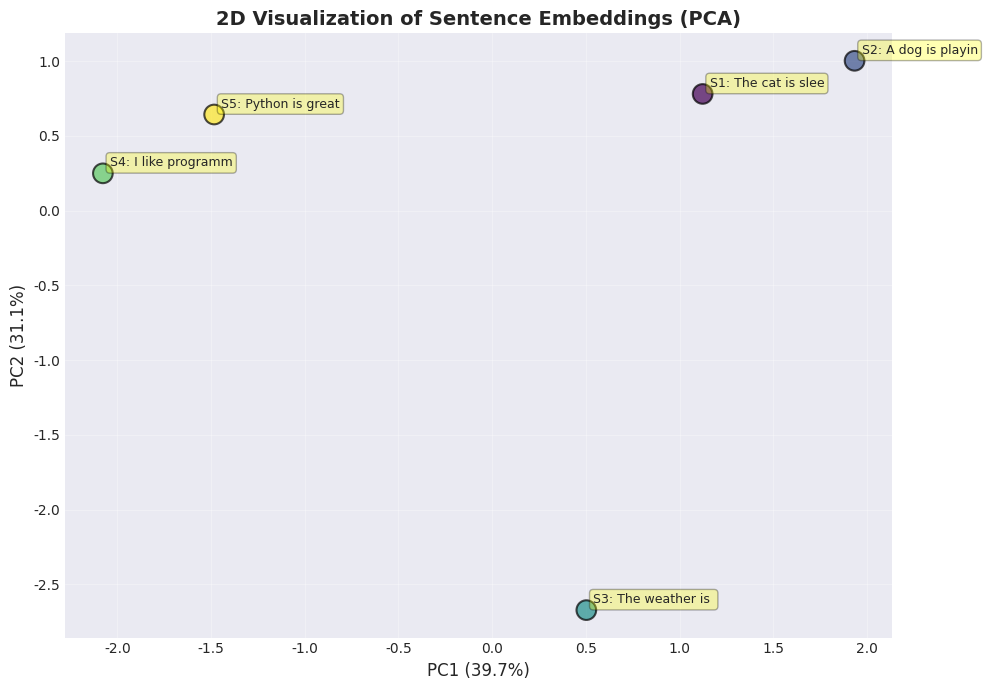


Visualization interpretation:
  Similar sentences → positioned close together
  Different sentences → positioned far apart


In [31]:
# 埋め込みを 2D に次元削減して可視化
from sklearn.decomposition import PCA

# ランダムシードを固定（再現性を確保）
np.random.seed(42)
torch.manual_seed(42)

# PCA で 2 次元に削減
pca = PCA(n_components=2, random_state=42)
embeddings_2d = pca.fit_transform(embeddings)

print(f"PCA 計算完了")
print(f"第1主成分の説明分散: {pca.explained_variance_ratio_[0]:.1%}")
print(f"第2主成分の説明分散: {pca.explained_variance_ratio_[1]:.1%}")
print(f"合計説明分散: {sum(pca.explained_variance_ratio_):.1%}\n")

# プロット
fig, ax = plt.subplots(figsize=(10, 7))

# 散布図を描画
scatter = ax.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], 
                     s=200, alpha=0.7, c=range(len(test_sentences)), 
                     cmap='viridis', edgecolors='black', linewidth=1.5)

# ラベルを追加
for i, sentence in enumerate(test_sentences):
    ax.annotate(f"S{i+1}: {sentence[:15]}", 
                xy=(embeddings_2d[i, 0], embeddings_2d[i, 1]), 
                xytext=(5, 5), textcoords='offset points',
                fontsize=9, bbox=dict(boxstyle='round,pad=0.3', 
                facecolor='yellow', alpha=0.3))

# ラベルとタイトルを設定（英語で文字化け対策）
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})", fontsize=12)
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})", fontsize=12)
ax.set_title("2D Visualization of Sentence Embeddings (PCA)", fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nVisualization interpretation:")
print(f"  Similar sentences → positioned close together")
print(f"  Different sentences → positioned far apart")

## 4️⃣ 簡易 RAG システムの実装

ベクトル検索を使った RAG システム

In [32]:
class SimpleRAG:
    """簡易 RAG システム"""
    
    def __init__(self):
        self.tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased')
        self.model = AutoModel.from_pretrained('distilbert-base-uncased')
        
        # 知識ベース
        self.knowledge_base = [
            "Python is a high-level programming language known for its simplicity.",
            "Machine learning is a subset of artificial intelligence.",
            "Deep learning uses neural networks with multiple layers.",
            "Natural language processing (NLP) deals with text analysis.",
            "Transformers are neural architectures based on attention mechanisms.",
            "TensorFlow and PyTorch are popular deep learning frameworks.",
        ]
        
        # 知識ベースの埋め込みを計算（事前計算）
        self.knowledge_embeddings = self._embed_texts(self.knowledge_base)
    
    def _embed_texts(self, texts):
        """テキストを埋め込み化"""
        encoded = self.tokenizer(
            texts,
            padding=True,
            return_tensors='pt',
            truncation=True,
            max_length=512
        )
        
        with torch.no_grad():
            output = self.model(**encoded)
        
        return output.last_hidden_state[:, 0, :].numpy()
    
    def retrieve(self, query, top_k=2):
        """クエリに関連した知識を検索"""
        # クエリを埋め込み化
        query_embedding = self._embed_texts([query])[0]
        
        # コサイン類似度計算
        similarities = cosine_similarity([query_embedding], self.knowledge_embeddings)[0]  # type: ignore
        
        # トップ-K を取得
        top_indices = np.argsort(similarities)[::-1][:top_k]
        
        return [
            {
                'text': self.knowledge_base[i],
                'score': similarities[i]
            }
            for i in top_indices
        ]

# RAG システムを初期化
rag = SimpleRAG()

print("="*60)
print("簡易 RAG システムのデモ")
print("="*60)

# テストクエリ
queries = [
    "What is machine learning?",
    "Tell me about deep learning",
    "Python programming"
]

for query in queries:
    print(f"\n質問: {query}")
    print("-" * 60)
    
    results = rag.retrieve(query, top_k=2)
    
    for i, result in enumerate(results, 1):
        print(f"\n検索結果 {i}:")
        print(f"  スコア: {result['score']:.4f}")
        print(f"  内容: {result['text'][:60]}...")

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 3563.83it/s]
DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


簡易 RAG システムのデモ

質問: What is machine learning?
------------------------------------------------------------

検索結果 1:
  スコア: 0.9396
  内容: Deep learning uses neural networks with multiple layers....

検索結果 2:
  スコア: 0.9301
  内容: Machine learning is a subset of artificial intelligence....

質問: Tell me about deep learning
------------------------------------------------------------

検索結果 1:
  スコア: 0.8937
  内容: Deep learning uses neural networks with multiple layers....

検索結果 2:
  スコア: 0.8710
  内容: Python is a high-level programming language known for its si...

質問: Python programming
------------------------------------------------------------

検索結果 1:
  スコア: 0.9383
  内容: Python is a high-level programming language known for its si...

検索結果 2:
  スコア: 0.9106
  内容: TensorFlow and PyTorch are popular deep learning frameworks....


## 5️⃣ 自律性スコアリング

AI の自立性を測定するスコアラー

In [33]:
class AutonomyScorer:
    """自律性スコアラー"""
    
    def __init__(self):
        self.criteria = [
            'planning',        # 計画性
            'learning',        # 学習性
            'adaptation',      # 適応性
            'decision_making', # 判断性
            'explainability',  # 説明性
            'efficiency',      # 効率性
            'reliability',     # 信頼性
            'robustness',      # 頑健性
            'exploration'      # 探索性
        ]
        self.scores = {criterion: 0.0 for criterion in self.criteria}
    
    def rate_criterion(self, criterion_name, score):
        """各基準にスコアを設定（0～100）"""
        if criterion_name in self.scores:
            self.scores[criterion_name] = min(max(score, 0), 100)
    
    def calculate_overall_score(self):
        """全体スコアを計算"""
        return sum(self.scores.values()) / len(self.scores)
    
    def get_report(self):
        """スコアリングレポート作成"""
        overall = self.calculate_overall_score()
        
        report = {
            'overall_score': overall,
            'criterion_scores': self.scores.copy()
        }
        
        return report

# スコアラーを使用
scorer = AutonomyScorer()

# サンプルスコアを設定
print("="*60)
print("自律性スコアリングの例")
print("="*60)

sample_scores = {
    'planning': 75,
    'learning': 82,
    'adaptation': 70,
    'decision_making': 88,
    'explainability': 79,
    'efficiency': 85,
    'reliability': 92,
    'robustness': 76,
    'exploration': 68
}

for criterion, score in sample_scores.items():
    scorer.rate_criterion(criterion, score)

# レポート表示
report = scorer.get_report()

print(f"\n📊 自律性スコアリングレポート")
print(f"\n全体スコア: {report['overall_score']:.1f}/100")
print(f"\n基準別スコア:")
print("-" * 40)

df_scores = pd.DataFrame([
    {'基準': k, 'スコア': v, 'ラベル': '●' * int(v/10) + '○' * (10 - int(v/10))}
    for k, v in report['criterion_scores'].items()
])

for _, row in df_scores.iterrows():
    print(f"{row['基準']:15} {row['スコア']:5.0f}/100 {row['ラベル']}")

自律性スコアリングの例

📊 自律性スコアリングレポート

全体スコア: 79.4/100

基準別スコア:
----------------------------------------
planning           75/100 ●●●●●●●○○○
learning           82/100 ●●●●●●●●○○
adaptation         70/100 ●●●●●●●○○○
decision_making    88/100 ●●●●●●●●○○
explainability     79/100 ●●●●●●●○○○
efficiency         85/100 ●●●●●●●●○○
reliability        92/100 ●●●●●●●●●○
robustness         76/100 ●●●●●●●○○○
exploration        68/100 ●●●●●●○○○○


## 6️⃣ インタラクティブな演習問題

学んだ内容を実践してみましょう

In [ ]:
print("="*60)                                                       # 演習問題 1: Tokenizer の理解
print("演習問題 1: Tokenizer の理解")# Tokenizer の基本的な動作を理解するための演習問題です。以下のテキストをトークン化し、トークン数を数えてください。
print("="*60)
print("\n問題: 次のテキストをトークン化し、トークン数を数えてください")
print("\nテキスト: 'I love learning about machine learning!'")

# 解答
tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')
test_text = "I love learning about machine learning!"
tokens = tokenizer.tokenize(test_text)

print(f"\n解答:")
print(f"  トークン: {tokens}")
print(f"  トークン数: {len(tokens)}")

演習問題 1: Tokenizer の理解

問題: 次のテキストをトークン化し、トークン数を数えてください

テキスト: 'I love learning about machine learning!'

解答:
  トークン: ['i', 'love', 'learning', 'about', 'machine', 'learning', '!']
  トークン数: 7


In [24]:
print("\n" + "="*60)
print("演習問題 2: 類似性の計算")
print("="*60)
print("\n問題: 次の2つのセンテンスの類似性を計算してください")
print("\nセンテンス1: 'I like cats'")
print("センテンス2: 'I love dogs'")

# 解答
sentences = ["I like cats", "I love dogs"]
embeds = get_embeddings(sentences)
sim = cosine_similarity(embeds)[0][1]

print(f"\n解答:")
print(f"  類似度: {sim:.4f}")
print(f"  解釈: {'高い類似性' if sim > 0.7 else '中程度の類似性' if sim > 0.5 else '低い類似性'}")


演習問題 2: 類似性の計算

問題: 次の2つのセンテンスの類似性を計算してください

センテンス1: 'I like cats'
センテンス2: 'I love dogs'

解答:
  類似度: 0.9910
  解釈: 高い類似性


In [ ]:
print("\n" + "="*60)
print("演習問題 3: RAG の実装")
print("="*60)
print("\n問題: 質問 'What are neural networks?' に対して")
print("知識ベースから最も関連性の高い情報を取得してください")

# 解答
query = "What are neural networks?"
results = rag.retrieve(query, top_k=1)                          # type: ignore retrieve メソッドを呼び出して、クエリに関連する知識を取得します。top_k=1 で最も関連性の高い1件を取得します。

print(f"\n解答:")
print(f"  クエリ: {query}")
print(f"  取得した知識: {results[0]['text']}")
print(f"  関連性スコア: {results[0]['score']:.4f}")


演習問題 3: RAG の実装

問題: 質問 'What are neural networks?' に対して
知識ベースから最も関連性の高い情報を取得してください

解答:
  クエリ: What are neural networks?
  取得した知識: Deep learning uses neural networks with multiple layers.
  関連性スコア: 0.9435


## 🎓 学習のまとめ

このノートブックで学んだことをまとめます

In [26]:
summary = """
🎓 このノートブックで学んだこと
================================

✅ 1. 最初の推論 (Hello LLM)
   - パイプラインを使った簡単な推論実装
   - テキスト分類、質問応答など複数のタスク

✅ 2. Tokenizer の詳細
   - トークン化のプロセス
   - 特殊トークン ([CLS], [SEP])
   - バッチ処理でのパディング・截断

✅ 3. 埋め込みベクトル
   - テキストを数値ベクトルに変換
   - コサイン類似度で意味的な近さを計算
   - 高次元ベクトルの 2D 可視化

✅ 4. RAG システム
   - ベクトル検索を使った関連知識の抽出
   - 知識ベースからの効率的な情報取得

✅ 5. 自律性スコアリング
   - 9つの基準での AI 評価
   - 全体スコアの計算

📚 次のステップ
==============
- プロジェクトの実装を読む
- カスタム知識ベースを追加
- モデルをファインチューニング
- 独自の評価指標を実装
"""

print(summary)


🎓 このノートブックで学んだこと

✅ 1. 最初の推論 (Hello LLM)
   - パイプラインを使った簡単な推論実装
   - テキスト分類、質問応答など複数のタスク

✅ 2. Tokenizer の詳細
   - トークン化のプロセス
   - 特殊トークン ([CLS], [SEP])
   - バッチ処理でのパディング・截断

✅ 3. 埋め込みベクトル
   - テキストを数値ベクトルに変換
   - コサイン類似度で意味的な近さを計算
   - 高次元ベクトルの 2D 可視化

✅ 4. RAG システム
   - ベクトル検索を使った関連知識の抽出
   - 知識ベースからの効率的な情報取得

✅ 5. 自律性スコアリング
   - 9つの基準での AI 評価
   - 全体スコアの計算

📚 次のステップ
- プロジェクトの実装を読む
- カスタム知識ベースを追加
- モデルをファインチューニング
- 独自の評価指標を実装



---

## 🚀 学習完了おめでとうございます！

このノートブックを通じて、LLM の基本から応用まで実装レベルで学習しました。

### 次に進むべきことは:
1. **プロジェクトのコード読解** - autonomous_rag_agent.py などの実装を学ぶ
2. **カスタマイズ** - 自分のデータで RAG を実装
3. **拡張** - 新しい機能を追加
4. **デプロイ** - アプリケーションをビルド

頑張ってください！
   